# Pipeline de Engenharia de Dados — Cibersegurança
## Camadas Bronze, Prata (Silver) e Ouro (Gold) + Modelo de Machine Learning

**Arquitetura Medallion:**
- **Bronze**: Dados brutos, rastreáveis, com mínima transformação
- **Silver**: Dados limpos, validados e confiáveis (por domínio)
- **Gold**: Dados prontos para consumo específico (ML)

---

## 1. Setup e Configuração

In [92]:
# ============================================================
# 1.1 - Importação de Bibliotecas
# ============================================================
import pandas as pd
import numpy as np
import hashlib
import json
import os
from datetime import datetime, timezone

# Visualização
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas com sucesso.")

✅ Bibliotecas importadas com sucesso.


In [ ]:
# ============================================================
# 1.1.1 - Configuração de renderer do Plotly para ambiente local
# ============================================================
import plotly.io as pio
pio.renderers.default = "png"
print(f"✅ Renderer do Plotly configurado para '{pio.renderers.default}'.")

✅ Renderer do Plotly configurado para 'png'.


In [54]:
# Dependências do renderer de gráficos no kernel ativo
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "nbformat", "kaleido", "-q"])
print("✅ nbformat e kaleido instalados no kernel ativo.")

✅ nbformat e kaleido instalados no kernel ativo.


In [55]:
import nbformat
import kaleido
import plotly.io as pio
print(f"nbformat: {nbformat.__version__}")
print("kaleido importado com sucesso")
print(f"Renderer atual do Plotly: {pio.renderers.default}")

nbformat: 5.10.4
kaleido importado com sucesso
Renderer atual do Plotly: png


In [56]:
import nbformat
import plotly.io._renderers as _plotly_renderers
_plotly_renderers.nbformat = nbformat
print("✅ Plotly renderer atualizado com nbformat no runtime.")

✅ Plotly renderer atualizado com nbformat no runtime.


In [57]:
# ============================================================
# 1.2 - Constantes e Caminhos
# ============================================================
from pathlib import Path

def find_project_root(start_path: Path) -> Path:
    """Sobe a árvore de diretórios até encontrar a raiz do projeto."""
    for candidate in [start_path] + list(start_path.parents):
        if (candidate / "incidents_master.csv").exists() and (candidate / "data").exists():
            return candidate
    return start_path

BASE_DIR = find_project_root(Path.cwd().resolve())
DATA_DIR = str(BASE_DIR / "data")
BRONZE_DIR = str(BASE_DIR / "data" / "bronze")
SILVER_DIR = str(BASE_DIR / "data" / "silver")
GOLD_DIR = str(BASE_DIR / "data" / "gold")
REPORTS_DIR = str(BASE_DIR / "reports")

# Criar pastas caso não existam
for d in [BRONZE_DIR, SILVER_DIR, GOLD_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Arquivos fonte
CSV_FILES = {
    "incidents_master": str(BASE_DIR / "incidents_master.csv"),
    "financial_impact": str(BASE_DIR / "financial_impact.csv"),
    "market_impact": str(BASE_DIR / "market_impact.csv"),
}

# Dicionário de regras de qualidade
QUALITY_RULES = {
    "invalid_date_order": "incident_date > discovery_date ou discovery_date > disclosure_date",
    "negative_price": "Preço de ação negativo (price_* < 0)",
    "missing_total_loss": "total_loss_usd é nulo",
    "loss_out_of_bounds": "total_loss fora dos limites [lower_bound, upper_bound]",
    "ransom_paid_exceeds_demanded": "ransom_paid_usd > ransom_demanded_usd",
    "quality_score_out_of_range": "quality_score fora do intervalo [0, 100]",
    "confidence_tier_invalid": "confidence_tier fora do intervalo [1, 4]",
    "duplicate_incident_id": "incident_id duplicado",
    "invalid_date_format": "Data em formato inválido ou fora do range 2019-2026",
    "negative_financial_value": "Valor financeiro negativo (direct_loss, recovery_cost, legal_fees)",
    "missing_incident_id": "incident_id ausente ou nulo",
}

print("✅ Constantes definidas.")
print(f"   Base: {BASE_DIR}")
print(f"   Bronze: {BRONZE_DIR}")
print(f"   Silver: {SILVER_DIR}")
print(f"   Gold:   {GOLD_DIR}")
print(f"   Reports: {REPORTS_DIR}")

✅ Constantes definidas.
   Base: C:\Users\vitho\Projeto-ciencia-dados
   Bronze: C:\Users\vitho\Projeto-ciencia-dados\data\bronze
   Silver: C:\Users\vitho\Projeto-ciencia-dados\data\silver
   Gold:   C:\Users\vitho\Projeto-ciencia-dados\data\gold
   Reports: C:\Users\vitho\Projeto-ciencia-dados\reports


---
## 2. Camada Bronze — Ingestão de Dados Brutos

**Regra de ouro:** Bronze NÃO toma decisões, só organiza.
- Leitura dos CSVs originais
- Padronização mínima de nomes de colunas (validar snake_case)
- Conversão de tipos **quando possível sem perda** (se falhar, manter como string)
- Salvamento em Parquet
- Registro de metadados de ingestão

In [58]:
# ============================================================
# 2.1 - Função de cálculo de hash SHA-256
# ============================================================
def compute_file_hash(filepath: str) -> str:
    """Calcula o hash SHA-256 de um arquivo."""
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            sha256.update(chunk)
    return sha256.hexdigest()

print("✅ Função de hash definida.")

✅ Função de hash definida.


In [59]:
# ============================================================
# 2.2 - Ingestão dos CSVs e conversão mínima (Bronze)
# ============================================================

# Colunas de data esperadas por tabela
DATE_COLS = {
    "incidents_master": ["incident_date", "discovery_date", "disclosure_date"],
    "financial_impact": [],
    "market_impact": [],
}

# Colunas de datetime (timestamps)
DATETIME_COLS = ["created_at", "updated_at"]

# Colunas booleanas esperadas
BOOL_COLS = {
    "incidents_master": ["is_public_company", "incident_date_estimated"],
    "financial_impact": [],
    "market_impact": ["earnings_announcement_within_7d"],
}

bronze_dfs = {}
metadata_ingestao = {}

for name, filepath in CSV_FILES.items():
    print(f"\n{'='*60}")
    print(f"Processando: {name}")
    print(f"{'='*60}")
    
    # Leitura bruta
    df = pd.read_csv(filepath)
    
    # Validar snake_case nos nomes de colunas
    df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]
    
    # Conversão segura de booleanos
    for col in BOOL_COLS.get(name, []):
        if col in df.columns:
            # Mapear TRUE/FALSE para bool; manter NaN como NaN
            bool_map = {"TRUE": True, "FALSE": False, "True": True, "False": False}
            df[col] = df[col].astype(str).map(bool_map)
            # Valores que não mapearam ficam como NaN (pd.NA)
            print(f"  ✓ Booleano convertido: {col}")
    
    # Conversão segura de datas (se falhar, manter como string)
    for col in DATE_COLS.get(name, []):
        if col in df.columns:
            converted = pd.to_datetime(df[col], errors="coerce", format="mixed")
            n_failed = converted.isna().sum() - df[col].isna().sum()
            if n_failed > 0:
                print(f"  ⚠ {col}: {n_failed} datas não convertidas (mantidas como string)")
                # Manter como string para tratar na Silver
            else:
                df[col] = converted
                print(f"  ✓ Data convertida: {col}")
    
    # Conversão segura de datetime timestamps
    for col in DATETIME_COLS:
        if col in df.columns:
            converted = pd.to_datetime(df[col], errors="coerce", format="mixed")
            n_failed = converted.isna().sum() - df[col].isna().sum()
            if n_failed > 0:
                print(f"  ⚠ {col}: {n_failed} timestamps não convertidos")
            else:
                df[col] = converted
                print(f"  ✓ Timestamp convertido: {col}")
    
    # Metadados de ingestão
    file_hash = compute_file_hash(filepath)
    meta = {
        "arquivo_origem": os.path.basename(filepath),
        "caminho_completo": filepath,
        "quantidade_linhas": len(df),
        "quantidade_colunas": len(df.columns),
        "colunas": list(df.columns),
        "tipos": {col: str(dtype) for col, dtype in df.dtypes.items()},
        "hash_sha256": file_hash,
        "data_hora_carga": datetime.now(timezone.utc).isoformat(),
    }
    metadata_ingestao[name] = meta
    
    # Salvar em CSV e Parquet
    csv_path = os.path.join(BRONZE_DIR, f"{name}.csv")
    parquet_path = os.path.join(BRONZE_DIR, f"{name}.parquet")
    df.to_csv(csv_path, index=False)
    df.to_parquet(parquet_path, index=False)
    
    bronze_dfs[name] = df
    
    print(f"  ✓ Salvo em: {csv_path}")
    print(f"  ✓ Salvo em: {parquet_path}")
    print(f"  → Linhas: {len(df)} | Colunas: {len(df.columns)} | Hash: {file_hash[:16]}...")

print("\n✅ Camada Bronze completa.")


Processando: incidents_master
  ✓ Booleano convertido: is_public_company
  ✓ Booleano convertido: incident_date_estimated
  ✓ Data convertida: incident_date
  ✓ Data convertida: discovery_date
  ✓ Data convertida: disclosure_date
  ✓ Timestamp convertido: created_at
  ✓ Timestamp convertido: updated_at
  ✓ Salvo em: C:\Users\vitho\Projeto-ciencia-dados\data\bronze\incidents_master.csv
  ✓ Salvo em: C:\Users\vitho\Projeto-ciencia-dados\data\bronze\incidents_master.parquet
  → Linhas: 850 | Colunas: 32 | Hash: 8d1a50b11b18167d...

Processando: financial_impact
  ✓ Timestamp convertido: created_at
  ✓ Timestamp convertido: updated_at
  ✓ Salvo em: C:\Users\vitho\Projeto-ciencia-dados\data\bronze\financial_impact.csv
  ✓ Salvo em: C:\Users\vitho\Projeto-ciencia-dados\data\bronze\financial_impact.parquet
  → Linhas: 778 | Colunas: 19 | Hash: a406a2d44d169978...

Processando: market_impact
  ✓ Booleano convertido: earnings_announcement_within_7d
  ✓ Timestamp convertido: created_at
  ✓ Time

In [60]:
# ============================================================
# 2.3 - Salvar metadados de ingestão
# ============================================================
metadata_path = os.path.join(BRONZE_DIR, "metadata_ingestao.json")
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata_ingestao, f, indent=2, ensure_ascii=False, default=str)

print(f"✅ Metadados salvos em: {metadata_path}")
print(f"\nResumo da ingestão:")
for name, meta in metadata_ingestao.items():
    print(f"  {name}: {meta['quantidade_linhas']} linhas, {meta['quantidade_colunas']} colunas")

✅ Metadados salvos em: C:\Users\vitho\Projeto-ciencia-dados\data\bronze\metadata_ingestao.json

Resumo da ingestão:
  incidents_master: 850 linhas, 32 colunas
  financial_impact: 778 linhas, 19 colunas
  market_impact: 358 linhas, 31 colunas


In [61]:
# ============================================================
# 2.4 - Visualização da Bronze (amostra)
# ============================================================
for name, df in bronze_dfs.items():
    print(f"\n{'='*60}")
    print(f"🔹 {name} — shape: {df.shape}")
    print(f"{'='*60}")
    print(df.dtypes.to_string())
    print(f"\nAmostra (3 primeiras linhas):")
    display(df.head(3))


🔹 incidents_master — shape: (850, 32)
incident_id                              object
company_name                             object
company_revenue_usd                     float64
country_hq                               object
industry_primary                         object
industry_secondary                       object
employee_count                            int64
is_public_company                          bool
stock_ticker                             object
incident_date                    datetime64[ns]
incident_date_estimated                    bool
discovery_date                   datetime64[ns]
disclosure_date                  datetime64[ns]
attack_vector_primary                    object
attack_vector_secondary                  object
attack_chain                             object
attributed_group                         object
attribution_confidence                   object
data_compromised_records                float64
data_type                                object
s

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,NaN,Multiple subsidiaries affected across 6 jurisd...,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,NaN,NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,NaN,NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00



🔹 financial_impact — shape: (778, 19)
incident_id                            object
direct_loss_usd                       float64
direct_loss_method                     object
ransom_demanded_usd                   float64
ransom_paid_usd                       float64
ransom_source                          object
recovery_cost_usd                     float64
legal_fees_usd                        float64
regulatory_fine_usd                   float64
insurance_payout_usd                  float64
total_loss_usd                        float64
total_loss_method                      object
total_loss_lower_bound                float64
total_loss_upper_bound                float64
inflation_adjusted_usd                float64
cpi_index_used                         object
notes                                  object
created_at                datetime64[ns, UTC]
updated_at                datetime64[ns, UTC]

Amostra (3 primeiras linhas):


,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_method,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,NaN,9455354.49,2496545.93,90695.25,6756288.97,24642595.67,calculated,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,NaN,5857150.47,1809188.41,NaN,2691027.33,15306810.06,disclosed,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
2,2023-0115-001,34881599.59,calculated,NaN,NaN,NaN,26404111.95,10330703.43,NaN,31759649.99,71616414.97,disclosed,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00



🔹 market_impact — shape: (358, 31)
incident_id                                     object
stock_ticker                                    object
price_7d_before                                float64
price_disclosure_day                           float64
price_1d_after                                 float64
price_7d_after                                 float64
price_30d_after                                float64
volume_avg_30d_baseline                          int64
volume_disclosure_day                            int64
sector_index                                    object
sector_return_same_period                      float64
abnormal_return_1d                             float64
abnormal_return_7d                             float64
abnormal_return_30d                            float64
car_neg1_to_pos1                               float64
car_0_to_7                                     float64
car_0_to_30                                    float64
car_0_to_90                  

,incident_id,stock_ticker,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_index,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2023-0115-001,BITW,262.07,251.95,245.11,250.34,246.87,19782288,48767234,S&P 500 Information Technology,...,1.000,True,1.181988e+11,2.4652,27.705,52.161,255.0,NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
1,2021-0315-001,SFM,9.37,9.09,8.73,8.78,8.67,458826,1421143,S&P 500 Consumer Discretionary,...,9.824,False,6.489114e+08,3.0973,17.116,27.638,324.0,NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
2,2021-1204-001,SQI,14.60,13.36,13.09,13.28,13.17,230932,354433,S&P 500 Information Technology,...,1.000,False,4.735164e+09,1.5348,38.209,45.756,19.0,NaN,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00


---
## 3. Data Lineage — Fluxo do Pipeline

O diagrama abaixo representa o fluxo completo dos dados, desde a origem até a camada Gold.

```mermaid
graph TD
    subgraph Origem["📁 Dados Brutos (CSV)"]
        A1[incidents_master.csv<br/>850 linhas, 32 colunas]
        A2[financial_impact.csv<br/>778 linhas, 19 colunas]
        A3[market_impact.csv<br/>358 linhas, 31 colunas]
    end

    subgraph Bronze["🥉 Camada Bronze (CSV + Parquet)"]
        B1[incidents_master.parquet]
        B2[financial_impact.parquet]
        B3[market_impact.parquet]
        B4[metadata_ingestao.json]
    end

    subgraph Validacao["🔍 Validação de Qualidade"]
        V1[Regras automáticas<br/>11 regras definidas]
        V2[quality_flags por registro]
        V3[Relatório de qualidade]
    end

    subgraph Silver["🥈 Camada Silver (CSV + Parquet)"]
        S1[incidents_silver.parquet<br/>+ is_valid, quality_flags<br/>+ features temporais]
        S2[financial_silver.parquet<br/>+ is_valid, quality_flags<br/>+ loss_ratio]
        S3[market_silver.parquet<br/>+ is_valid, quality_flags]
    end

    subgraph Gold["🥇 Camada Gold"]
        G1[dataset_ml_final.parquet<br/>Merge das 3 tabelas<br/>+ severity_label<br/>- colunas com leakage]
    end

    subgraph ML["🤖 Machine Learning"]
        M1[Train/Test Split]
        M2[Random Forest]
        M3[Gradient Boosting]
        M4[Avaliação e Métricas]
    end

    A1 -->|Leitura + tipos seguros| B1
    A2 -->|Leitura + tipos seguros| B2
    A3 -->|Leitura + tipos seguros| B3
    A1 & A2 & A3 -->|Hash SHA-256 + contagem| B4

    B1 --> V1
    B2 --> V1
    B3 --> V1
    V1 --> V2
    V2 --> V3

    B1 -->|Dedup + flags + features| S1
    B2 -->|Dedup + flags + loss_ratio| S2
    B3 -->|Dedup + flags + limpeza| S3
    V2 -->|quality_flags| S1
    V2 -->|quality_flags| S2
    V2 -->|quality_flags| S3

    S1 -->|LEFT JOIN incident_id| G1
    S2 -->|LEFT JOIN incident_id| G1
    S3 -->|LEFT JOIN incident_id| G1

    G1 --> M1
    M1 --> M2
    M1 --> M3
    M2 --> M4
    M3 --> M4

    style Origem fill:#f9f9f9,stroke:#333
    style Bronze fill:#cd7f32,stroke:#333,color:#fff
    style Validacao fill:#ffd700,stroke:#333
    style Silver fill:#c0c0c0,stroke:#333
    style Gold fill:#ffd700,stroke:#333
    style ML fill:#4CAF50,stroke:#333,color:#fff
```

### Detalhamento das Transformações

| Etapa | Ação | Colunas Afetadas |
|---|---|---|
| **CSV → Bronze** | Leitura, tipos seguros (bool/date/datetime), snake_case, persistência em Parquet | Todas |
| **Bronze → Validação** | 11 regras automáticas, geração de quality_flags | incident_date, total_loss_usd, ransom_*, price_*, etc. |
| **Bronze → Silver** | Dedup, is_valid, quality_flags, features derivadas, remoção de colunas admin | created_at, updated_at, notes removidas; features temporais criadas |
| **Silver → Gold** | Merge (LEFT JOIN), criação de severity_label, remoção de leakage | total_loss_usd (usado para label e removido), colunas pós-incidente removidas |
| **Gold → ML** | Encoding, scaling, split, treino de modelos | Todas as features restantes |

---
## 4. Análise de Qualidade dos Dados (Camada Bronze)

Verificação de problemas nos dados brutos:
- Valores nulos
- Duplicatas
- Categorias inconsistentes
- Datas fora do padrão
- Regras automáticas de validação

In [62]:
# ============================================================
# 4.1 - Análise de Nulos
# ============================================================
print("=" * 80)
print("ANÁLISE DE VALORES NULOS")
print("=" * 80)

for name, df in bronze_dfs.items():
    print(f"\n🔹 {name} ({df.shape[0]} linhas)")
    print("-" * 60)
    null_info = df.isnull().sum()
    null_pct = (df.isnull().sum() / len(df) * 100).round(2)
    null_report = pd.DataFrame({
        "nulos": null_info,
        "percentual (%)": null_pct
    })
    null_report = null_report[null_report["nulos"] > 0].sort_values("percentual (%)", ascending=False)
    if len(null_report) > 0:
        display(null_report)
    else:
        print("  Nenhum valor nulo encontrado.")

ANÁLISE DE VALORES NULOS

🔹 incidents_master (850 linhas)
------------------------------------------------------------


,nulos,percentual (%)
review_flag,780,91.76
industry_secondary,697,82.00
attack_vector_secondary,639,75.18
notes,636,74.82
data_source_secondary,464,54.59
stock_ticker,438,51.53
downtime_hours,430,50.59
attribution_confidence,368,43.29
attributed_group,368,43.29
attack_chain,275,32.35



🔹 financial_impact (778 linhas)
------------------------------------------------------------


,nulos,percentual (%)
ransom_paid_usd,692,88.95
ransom_source,692,88.95
regulatory_fine_usd,646,83.03
ransom_demanded_usd,572,73.52
notes,530,68.12
insurance_payout_usd,343,44.09



🔹 market_impact (358 linhas)
------------------------------------------------------------


,nulos,percentual (%)
notes,266,74.30
days_to_price_recovery,36,10.06


In [63]:
# ============================================================
# 4.2 - Análise de Duplicatas
# ============================================================
print("=" * 80)
print("ANÁLISE DE DUPLICATAS")
print("=" * 80)

for name, df in bronze_dfs.items():
    n_dup_rows = df.duplicated().sum()
    n_dup_id = df.duplicated(subset=["incident_id"]).sum() if "incident_id" in df.columns else "N/A"
    print(f"\n🔹 {name}")
    print(f"  Linhas duplicadas completas: {n_dup_rows}")
    print(f"  incident_id duplicados:      {n_dup_id}")

ANÁLISE DE DUPLICATAS

🔹 incidents_master
  Linhas duplicadas completas: 0
  incident_id duplicados:      0

🔹 financial_impact
  Linhas duplicadas completas: 0
  incident_id duplicados:      0

🔹 market_impact
  Linhas duplicadas completas: 0
  incident_id duplicados:      0


In [64]:
# ============================================================
# 4.3 - Análise de Categorias 
# ============================================================
print("=" * 80)
print("ANÁLISE DE CATEGORIAS (valores únicos)")
print("=" * 80)

cat_cols_check = {
    "incidents_master": [
        "attack_vector_primary", "attack_vector_secondary", "attribution_confidence",
        "data_type", "data_source_type", "confidence_tier", "quality_grade", "country_hq"
    ],
    "financial_impact": ["direct_loss_method", "total_loss_method"],
    "market_impact": ["sector_index"],
}

for name, cols in cat_cols_check.items():
    df = bronze_dfs[name]
    print(f"\n🔹 {name}")
    print("-" * 60)
    for col in cols:
        if col in df.columns:
            unique_vals = df[col].dropna().unique()
            print(f"\n  {col} ({len(unique_vals)} valores únicos):")
            for v in sorted(unique_vals.astype(str)):
                count = (df[col].astype(str) == v).sum()
                print(f"    - {v}: {count}")

ANÁLISE DE CATEGORIAS (valores únicos)

🔹 incidents_master
------------------------------------------------------------

  attack_vector_primary (9 valores únicos):
    - apt: 84
    - backdoor: 30
    - data_breach: 123
    - ddos: 67
    - malware: 79
    - phishing: 147
    - ransomware: 228
    - supply_chain: 58
    - trojan: 34

  attack_vector_secondary (9 valores únicos):
    - apt: 19
    - backdoor: 23
    - data_breach: 23
    - ddos: 27
    - malware: 24
    - phishing: 31
    - ransomware: 17
    - supply_chain: 28
    - trojan: 19

  attribution_confidence (4 valores únicos):
    - confirmed: 63
    - probable: 172
    - suspected: 168
    - unknown: 79

  data_type (6 valores únicos):
    - IP: 48
    - PII: 168
    - credentials: 75
    - financial: 82
    - health: 69
    - mixed: 160

  data_source_type (5 valores únicos):
    - company_pr: 136
    - cybersecurity_firm: 159
    - gdpr_notification: 154
    - sec_filing: 187
    - verified_media: 214

  confidence_tier

In [65]:
# ============================================================
# 4.4 - Validação de Datas
# ============================================================
print("=" * 80)
print("VALIDAÇÃO DE DATAS")
print("=" * 80)

df_inc = bronze_dfs["incidents_master"]

date_cols = ["incident_date", "discovery_date", "disclosure_date"]
for col in date_cols:
    if col in df_inc.columns:
        if pd.api.types.is_datetime64_any_dtype(df_inc[col]):
            min_date = df_inc[col].min()
            max_date = df_inc[col].max()
            out_of_range = ((df_inc[col] < "2019-01-01") | (df_inc[col] > "2026-12-31")).sum()
            print(f"\n  {col}:")
            print(f"    Min: {min_date} | Max: {max_date}")
            print(f"    Fora do range 2019-2026: {out_of_range}")
        else:
            print(f"\n  {col}: tipo {df_inc[col].dtype} (não convertido para datetime)")

VALIDAÇÃO DE DATAS

  incident_date:
    Min: 2021-01-01 00:00:00 | Max: 2025-12-31 00:00:00
    Fora do range 2019-2026: 0

  discovery_date:
    Min: 2021-01-16 00:00:00 | Max: 2026-07-04 00:00:00
    Fora do range 2019-2026: 0

  disclosure_date:
    Min: 2021-01-27 00:00:00 | Max: 2026-07-19 00:00:00
    Fora do range 2019-2026: 0


In [66]:
# ============================================================
# 4.5 - Regras Automáticas de Validação
# ============================================================
print("=" * 80)
print("REGRAS AUTOMÁTICAS DE VALIDAÇÃO")
print("=" * 80)

df_inc = bronze_dfs["incidents_master"]
df_fin = bronze_dfs["financial_impact"]
df_mkt = bronze_dfs["market_impact"]

results = {}

# --- incidents_master ---
# R1: incident_date <= discovery_date <= disclosure_date
if pd.api.types.is_datetime64_any_dtype(df_inc["incident_date"]):
    mask_date = (
        (df_inc["incident_date"] > df_inc["discovery_date"]) |
        (df_inc["discovery_date"] > df_inc["disclosure_date"])
    )
    # Ignorar NaN
    mask_date = mask_date.fillna(False)
    n_fail = mask_date.sum()
    results["invalid_date_order"] = n_fail
    print(f"\n  ❌ invalid_date_order: {n_fail} registros")
else:
    results["invalid_date_order"] = "N/A (datas como string)"
    print(f"\n  ⚠ invalid_date_order: N/A (datas não convertidas)")

# R2: quality_score entre 0 e 100
mask_qs = (df_inc["quality_score"] < 0) | (df_inc["quality_score"] > 100)
mask_qs = mask_qs.fillna(False)
results["quality_score_out_of_range"] = mask_qs.sum()
print(f"  ❌ quality_score_out_of_range: {mask_qs.sum()} registros")

# R3: confidence_tier entre 1 e 4
mask_ct = (df_inc["confidence_tier"] < 1) | (df_inc["confidence_tier"] > 4)
mask_ct = mask_ct.fillna(False)
results["confidence_tier_invalid"] = mask_ct.sum()
print(f"  ❌ confidence_tier_invalid: {mask_ct.sum()} registros")

# R4: duplicate incident_id
dup_ids_inc = df_inc["incident_id"].duplicated().sum()
results["duplicate_incident_id_incidents"] = dup_ids_inc
print(f"  ❌ duplicate_incident_id (incidents): {dup_ids_inc}")

# R5: missing incident_id
missing_id_inc = df_inc["incident_id"].isna().sum()
results["missing_incident_id_incidents"] = missing_id_inc
print(f"  ❌ missing_incident_id (incidents): {missing_id_inc}")

# --- financial_impact ---
# R6: total_loss_usd nulo
missing_tl = df_fin["total_loss_usd"].isna().sum()
results["missing_total_loss"] = missing_tl
print(f"\n  ❌ missing_total_loss: {missing_tl} registros")

# R7: total_loss fora dos bounds
if "total_loss_lower_bound" in df_fin.columns and "total_loss_upper_bound" in df_fin.columns:
    mask_bounds = (
        (df_fin["total_loss_usd"] < df_fin["total_loss_lower_bound"]) |
        (df_fin["total_loss_usd"] > df_fin["total_loss_upper_bound"])
    )
    mask_bounds = mask_bounds.fillna(False)
    results["loss_out_of_bounds"] = mask_bounds.sum()
    print(f"  ❌ loss_out_of_bounds: {mask_bounds.sum()} registros")

# R8: ransom_paid > ransom_demanded
mask_ransom = df_fin["ransom_paid_usd"] > df_fin["ransom_demanded_usd"]
mask_ransom = mask_ransom.fillna(False)
results["ransom_paid_exceeds_demanded"] = mask_ransom.sum()
print(f"  ❌ ransom_paid_exceeds_demanded: {mask_ransom.sum()} registros")

# R9: negative financial values
for fin_col in ["direct_loss_usd", "recovery_cost_usd", "legal_fees_usd"]:
    if fin_col in df_fin.columns:
        mask_neg = df_fin[fin_col] < 0
        mask_neg = mask_neg.fillna(False)
        results[f"negative_{fin_col}"] = mask_neg.sum()
        print(f"  ❌ negative_{fin_col}: {mask_neg.sum()} registros")

# --- market_impact ---
# R10: preços negativos
price_cols = [c for c in df_mkt.columns if c.startswith("price_")]
for pc in price_cols:
    mask_neg = df_mkt[pc] < 0
    mask_neg = mask_neg.fillna(False)
    results[f"negative_{pc}"] = mask_neg.sum()
    print(f"  ❌ negative_{pc}: {mask_neg.sum()} registros")

print("\n" + "=" * 80)
print("RESUMO DAS VALIDAÇÕES")
print("=" * 80)
for rule, count in results.items():
    status = "✅ OK" if (isinstance(count, int) and count == 0) else f"⚠️ {count}"
    print(f"  {rule}: {status}")

REGRAS AUTOMÁTICAS DE VALIDAÇÃO

  ❌ invalid_date_order: 0 registros
  ❌ quality_score_out_of_range: 0 registros
  ❌ confidence_tier_invalid: 0 registros
  ❌ duplicate_incident_id (incidents): 0
  ❌ missing_incident_id (incidents): 0

  ❌ missing_total_loss: 0 registros
  ❌ loss_out_of_bounds: 0 registros
  ❌ ransom_paid_exceeds_demanded: 0 registros
  ❌ negative_direct_loss_usd: 0 registros
  ❌ negative_recovery_cost_usd: 0 registros
  ❌ negative_legal_fees_usd: 0 registros
  ❌ negative_price_7d_before: 0 registros
  ❌ negative_price_disclosure_day: 0 registros
  ❌ negative_price_1d_after: 0 registros
  ❌ negative_price_7d_after: 0 registros
  ❌ negative_price_30d_after: 0 registros

RESUMO DAS VALIDAÇÕES
  invalid_date_order: ⚠️ 0
  quality_score_out_of_range: ⚠️ 0
  confidence_tier_invalid: ⚠️ 0
  duplicate_incident_id_incidents: ⚠️ 0
  missing_incident_id_incidents: ⚠️ 0
  missing_total_loss: ⚠️ 0
  loss_out_of_bounds: ⚠️ 0
  ransom_paid_exceeds_demanded: ⚠️ 0
  negative_direct_los

In [67]:
# ============================================================
# 4.6 - Relatório de Qualidade Consolidado
# ============================================================
print("=" * 80)
print("📋 RELATÓRIO DE QUALIDADE DOS DADOS")
print("=" * 80)

quality_report = []
for name, df in bronze_dfs.items():
    total_cells = df.shape[0] * df.shape[1]
    null_cells = df.isnull().sum().sum()
    dup_rows = df.duplicated().sum()
    dup_ids = df.duplicated(subset=["incident_id"]).sum() if "incident_id" in df.columns else 0
    
    quality_report.append({
        "Tabela": name,
        "Linhas": df.shape[0],
        "Colunas": df.shape[1],
        "Células Totais": total_cells,
        "Células Nulas": null_cells,
        "% Nulos": round(null_cells / total_cells * 100, 2),
        "Duplicatas (linhas)": dup_rows,
        "Duplicatas (ID)": dup_ids,
    })

df_quality = pd.DataFrame(quality_report)
display(df_quality)

# Resumo geral
total_validations = sum(v for v in results.values() if isinstance(v, int))
print(f"\nTotal de violações de regras encontradas: {total_validations}")
print(f"Regras com violações: {sum(1 for v in results.values() if isinstance(v, int) and v > 0)}")
print(f"Regras sem violações: {sum(1 for v in results.values() if isinstance(v, int) and v == 0)}")

# Salvar relatório em arquivo para entrega
quality_report_path = os.path.join(REPORTS_DIR, "data_quality_report.md")
with open(quality_report_path, "w", encoding="utf-8") as f:
    f.write("# Relatório de Qualidade dos Dados\n\n")
    f.write("## Resumo por camada Bronze\n\n")
    f.write(df_quality.to_string(index=False))
    f.write("\n\n## Regras automáticas\n\n")
    for rule, count in results.items():
        f.write(f"- {rule}: {count}\n")
    f.write("\n## Observações\n\n")
    f.write("- Bronze preserva os arquivos originais com padronização mínima.\n")
    f.write("- Silver mantém quality_flags e is_valid por registro.\n")
    f.write("- Reexecute este relatório após atualizar os CSVs de origem.\n")

print(f"\n✅ Relatório salvo em: {quality_report_path}")

📋 RELATÓRIO DE QUALIDADE DOS DADOS


,Tabela,Linhas,Colunas,Células Totais,Células Nulas,% Nulos,Duplicatas (linhas),Duplicatas (ID)
0,incidents_master,850,32,27200,5591,20.56,0,0
1,financial_impact,778,19,14782,3475,23.51,0,0
2,market_impact,358,31,11098,302,2.72,0,0



Total de violações de regras encontradas: 0
Regras com violações: 0
Regras sem violações: 0

✅ Relatório salvo em: C:\Users\vitho\Projeto-ciencia-dados\reports\data_quality_report.md


---
## 5. Camada Silver — Dados Limpos e Confiáveis

**Princípios:**
- NÃO remove registros inválidos → cria `is_valid` e `quality_flags`
- Remoção de duplicatas por `incident_id`
- Tratamento de nulos e categorias
- Criação de features derivadas genéricas
- Tabelas mantidas **separadas** por domínio
- Remoção de colunas puramente administrativas

In [68]:
# ============================================================
# 5.1 - Silver: incidents_master
# ============================================================
df_inc_s = bronze_dfs["incidents_master"].copy()

# --- Deduplicação ---
n_before = len(df_inc_s)
df_inc_s = df_inc_s.drop_duplicates(subset=["incident_id"], keep="first")
n_after = len(df_inc_s)
print(f"Deduplicação incidents: {n_before} → {n_after} ({n_before - n_after} removidas)")

# --- Quality Flags ---
def compute_quality_flags_incidents(row):
    flags = []
    
    # R1: Ordem das datas
    try:
        if pd.notna(row["incident_date"]) and pd.notna(row["discovery_date"]):
            if row["incident_date"] > row["discovery_date"]:
                flags.append("invalid_date_order")
        if pd.notna(row["discovery_date"]) and pd.notna(row["disclosure_date"]):
            if row["discovery_date"] > row["disclosure_date"]:
                flags.append("invalid_date_order")
    except (TypeError, ValueError):
        flags.append("invalid_date_format")
    
    # R2: quality_score
    if pd.notna(row.get("quality_score")):
        if row["quality_score"] < 0 or row["quality_score"] > 100:
            flags.append("quality_score_out_of_range")
    
    # R3: confidence_tier
    if pd.notna(row.get("confidence_tier")):
        if row["confidence_tier"] < 1 or row["confidence_tier"] > 4:
            flags.append("confidence_tier_invalid")
    
    # R4: incident_id ausente
    if pd.isna(row.get("incident_id")) or str(row.get("incident_id")).strip() == "":
        flags.append("missing_incident_id")
    
    return flags

df_inc_s["quality_flags"] = df_inc_s.apply(compute_quality_flags_incidents, axis=1)
df_inc_s["is_valid"] = df_inc_s["quality_flags"].apply(lambda x: len(x) == 0)

print(f"\nRegistros válidos: {df_inc_s['is_valid'].sum()} / {len(df_inc_s)}")
print(f"Registros com flags: {(~df_inc_s['is_valid']).sum()}")

# --- Features derivadas (genéricas, temporais) ---
if pd.api.types.is_datetime64_any_dtype(df_inc_s["incident_date"]):
    df_inc_s["incident_year"] = df_inc_s["incident_date"].dt.year
    df_inc_s["incident_month"] = df_inc_s["incident_date"].dt.month
    df_inc_s["incident_dow"] = df_inc_s["incident_date"].dt.dayofweek  # 0=Monday

if (pd.api.types.is_datetime64_any_dtype(df_inc_s["incident_date"]) and 
    pd.api.types.is_datetime64_any_dtype(df_inc_s["discovery_date"])):
    df_inc_s["days_to_discovery"] = (df_inc_s["discovery_date"] - df_inc_s["incident_date"]).dt.days

if (pd.api.types.is_datetime64_any_dtype(df_inc_s["discovery_date"]) and 
    pd.api.types.is_datetime64_any_dtype(df_inc_s["disclosure_date"])):
    df_inc_s["days_to_disclosure"] = (df_inc_s["disclosure_date"] - df_inc_s["discovery_date"]).dt.days

print("\nFeatures temporais criadas: incident_year, incident_month, incident_dow, days_to_discovery, days_to_disclosure")

# --- Remoção de colunas administrativas ---
cols_to_drop = ["created_at", "updated_at", "notes"]
df_inc_s = df_inc_s.drop(columns=[c for c in cols_to_drop if c in df_inc_s.columns])
print(f"Colunas removidas: {cols_to_drop}")

# --- Converter quality_flags para string (para CSV/Parquet) ---
df_inc_s["quality_flags_str"] = df_inc_s["quality_flags"].apply(lambda x: "|".join(x) if x else "")

# Salvar
silver_inc_path = os.path.join(SILVER_DIR, "incidents_silver.csv")
silver_inc_parquet_path = os.path.join(SILVER_DIR, "incidents_silver.parquet")
df_save = df_inc_s.drop(columns=["quality_flags"])
df_save.to_csv(silver_inc_path, index=False)
df_save.to_parquet(silver_inc_parquet_path, index=False)
print(f"\n✅ Salvo: {silver_inc_path} ({len(df_save)} linhas, {len(df_save.columns)} colunas)")
print(f"✅ Salvo: {silver_inc_parquet_path}")

Deduplicação incidents: 850 → 850 (0 removidas)

Registros válidos: 850 / 850
Registros com flags: 0

Features temporais criadas: incident_year, incident_month, incident_dow, days_to_discovery, days_to_disclosure
Colunas removidas: ['created_at', 'updated_at', 'notes']

✅ Salvo: C:\Users\vitho\Projeto-ciencia-dados\data\silver\incidents_silver.csv (850 linhas, 36 colunas)
✅ Salvo: C:\Users\vitho\Projeto-ciencia-dados\data\silver\incidents_silver.parquet


In [69]:
# ============================================================
# 5.2 - Silver: financial_impact
# ============================================================
df_fin_s = bronze_dfs["financial_impact"].copy()

# --- Deduplicação ---
n_before = len(df_fin_s)
df_fin_s = df_fin_s.drop_duplicates(subset=["incident_id"], keep="first")
n_after = len(df_fin_s)
print(f"Deduplicação financial: {n_before} → {n_after} ({n_before - n_after} removidas)")

# --- Quality Flags ---
def compute_quality_flags_financial(row):
    flags = []
    
    # missing total_loss
    if pd.isna(row.get("total_loss_usd")):
        flags.append("missing_total_loss")
    
    # loss out of bounds
    if (pd.notna(row.get("total_loss_usd")) and 
        pd.notna(row.get("total_loss_lower_bound")) and
        pd.notna(row.get("total_loss_upper_bound"))):
        if (row["total_loss_usd"] < row["total_loss_lower_bound"] or
            row["total_loss_usd"] > row["total_loss_upper_bound"]):
            flags.append("loss_out_of_bounds")
    
    # ransom_paid > ransom_demanded
    if pd.notna(row.get("ransom_paid_usd")) and pd.notna(row.get("ransom_demanded_usd")):
        if row["ransom_paid_usd"] > row["ransom_demanded_usd"]:
            flags.append("ransom_paid_exceeds_demanded")
    
    # negative financial values
    for col in ["direct_loss_usd", "recovery_cost_usd", "legal_fees_usd"]:
        if pd.notna(row.get(col)) and row[col] < 0:
            flags.append(f"negative_{col}")
    
    # missing incident_id
    if pd.isna(row.get("incident_id")) or str(row.get("incident_id")).strip() == "":
        flags.append("missing_incident_id")
    
    return flags

df_fin_s["quality_flags"] = df_fin_s.apply(compute_quality_flags_financial, axis=1)
df_fin_s["is_valid"] = df_fin_s["quality_flags"].apply(lambda x: len(x) == 0)

print(f"\nRegistros válidos: {df_fin_s['is_valid'].sum()} / {len(df_fin_s)}")

# --- Feature derivada: loss_ratio (segura) ---
df_fin_s["loss_ratio"] = np.where(
    df_fin_s["total_loss_usd"] > 0,
    df_fin_s["direct_loss_usd"] / df_fin_s["total_loss_usd"],
    np.nan
)
print(f"loss_ratio calculado (valores válidos: {df_fin_s['loss_ratio'].notna().sum()})")

# --- Remoção de colunas administrativas ---
cols_to_drop = ["created_at", "updated_at", "notes"]
df_fin_s = df_fin_s.drop(columns=[c for c in cols_to_drop if c in df_fin_s.columns])
print(f"Colunas removidas: {cols_to_drop}")

# --- Converter quality_flags para string (para CSV/Parquet) ---
df_fin_s["quality_flags_str"] = df_fin_s["quality_flags"].apply(lambda x: "|".join(x) if x else "")

# Salvar
silver_fin_path = os.path.join(SILVER_DIR, "financial_silver.csv")
silver_fin_parquet_path = os.path.join(SILVER_DIR, "financial_silver.parquet")
df_save = df_fin_s.drop(columns=["quality_flags"])
df_save.to_csv(silver_fin_path, index=False)
df_save.to_parquet(silver_fin_parquet_path, index=False)
print(f"\n✅ Salvo: {silver_fin_path} ({len(df_save)} linhas, {len(df_save.columns)} colunas)")
print(f"✅ Salvo: {silver_fin_parquet_path}")

Deduplicação financial: 778 → 778 (0 removidas)

Registros válidos: 778 / 778
loss_ratio calculado (valores válidos: 778)
Colunas removidas: ['created_at', 'updated_at', 'notes']

✅ Salvo: C:\Users\vitho\Projeto-ciencia-dados\data\silver\financial_silver.csv (778 linhas, 19 colunas)
✅ Salvo: C:\Users\vitho\Projeto-ciencia-dados\data\silver\financial_silver.parquet


In [70]:
# ============================================================
# 5.3 - Silver: market_impact
# ============================================================
df_mkt_s = bronze_dfs["market_impact"].copy()

# --- Deduplicação ---
n_before = len(df_mkt_s)
df_mkt_s = df_mkt_s.drop_duplicates(subset=["incident_id"], keep="first")
n_after = len(df_mkt_s)
print(f"Deduplicação market: {n_before} → {n_after} ({n_before - n_after} removidas)")

# --- Quality Flags ---
def compute_quality_flags_market(row):
    flags = []
    
    # negative prices
    price_cols = [c for c in row.index if c.startswith("price_")]
    for pc in price_cols:
        if pd.notna(row.get(pc)) and row[pc] < 0:
            flags.append(f"negative_{pc}")
            break  # uma flag basta para indicar preço negativo
    
    # missing incident_id
    if pd.isna(row.get("incident_id")) or str(row.get("incident_id")).strip() == "":
        flags.append("missing_incident_id")
    
    return flags

df_mkt_s["quality_flags"] = df_mkt_s.apply(compute_quality_flags_market, axis=1)
df_mkt_s["is_valid"] = df_mkt_s["quality_flags"].apply(lambda x: len(x) == 0)

print(f"\nRegistros válidos: {df_mkt_s['is_valid'].sum()} / {len(df_mkt_s)}")

# --- Remoção de colunas administrativas ---
cols_to_drop = ["created_at", "updated_at", "notes"]
df_mkt_s = df_mkt_s.drop(columns=[c for c in cols_to_drop if c in df_mkt_s.columns])
print(f"Colunas removidas: {cols_to_drop}")

# --- Converter quality_flags para string (para CSV/Parquet) ---
df_mkt_s["quality_flags_str"] = df_mkt_s["quality_flags"].apply(lambda x: "|".join(x) if x else "")

# Salvar
silver_mkt_path = os.path.join(SILVER_DIR, "market_silver.csv")
silver_mkt_parquet_path = os.path.join(SILVER_DIR, "market_silver.parquet")
df_save = df_mkt_s.drop(columns=["quality_flags"])
df_save.to_csv(silver_mkt_path, index=False)
df_save.to_parquet(silver_mkt_parquet_path, index=False)
print(f"\n✅ Salvo: {silver_mkt_path} ({len(df_save)} linhas, {len(df_save.columns)} colunas)")
print(f"✅ Salvo: {silver_mkt_parquet_path}")

Deduplicação market: 358 → 358 (0 removidas)

Registros válidos: 358 / 358
Colunas removidas: ['created_at', 'updated_at', 'notes']

✅ Salvo: C:\Users\vitho\Projeto-ciencia-dados\data\silver\market_silver.csv (358 linhas, 30 colunas)
✅ Salvo: C:\Users\vitho\Projeto-ciencia-dados\data\silver\market_silver.parquet


In [71]:
# ============================================================
# 5.4 - Resumo da Camada Silver
# ============================================================
print("=" * 80)
print("📋 RESUMO DA CAMADA SILVER")
print("=" * 80)

silver_summary = []
for name, df in [("incidents_silver", df_inc_s), ("financial_silver", df_fin_s), ("market_silver", df_mkt_s)]:
    silver_summary.append({
        "Tabela": name,
        "Linhas": len(df),
        "Colunas": len(df.columns),
        "Válidos": df["is_valid"].sum(),
        "Inválidos": (~df["is_valid"]).sum(),
        "% Válidos": round(df["is_valid"].mean() * 100, 2),
    })

display(pd.DataFrame(silver_summary))

# Mostrar distribuição de flags
print("\nDistribuição de quality_flags (incidents):")
all_flags_inc = [f for flags in df_inc_s["quality_flags"] for f in flags]
if all_flags_inc:
    display(pd.Series(all_flags_inc).value_counts().to_frame("count"))
else:
    print("  Nenhuma flag encontrada.")

print("\nDistribuição de quality_flags (financial):")
all_flags_fin = [f for flags in df_fin_s["quality_flags"] for f in flags]
if all_flags_fin:
    display(pd.Series(all_flags_fin).value_counts().to_frame("count"))
else:
    print("  Nenhuma flag encontrada.")

print("\nDistribuição de quality_flags (market):")
all_flags_mkt = [f for flags in df_mkt_s["quality_flags"] for f in flags]
if all_flags_mkt:
    display(pd.Series(all_flags_mkt).value_counts().to_frame("count"))
else:
    print("  Nenhuma flag encontrada.")

📋 RESUMO DA CAMADA SILVER


,Tabela,Linhas,Colunas,Válidos,Inválidos,% Válidos
0,incidents_silver,850,37,850,0,100.0
1,financial_silver,778,20,778,0,100.0
2,market_silver,358,31,358,0,100.0



Distribuição de quality_flags (incidents):
  Nenhuma flag encontrada.

Distribuição de quality_flags (financial):
  Nenhuma flag encontrada.

Distribuição de quality_flags (market):
  Nenhuma flag encontrada.


---
## 6. Camada Gold — Dataset Preparado para ML

**Responsabilidades da Gold:**
- Merge das 3 tabelas Silver (LEFT JOIN por incident_id)
- Criação do label: `severity_label`
- Remoção de colunas com data leakage
- Tabela checklist anti-leakage
- Validação pós-merge

In [72]:
# ============================================================
# 6.1 - Merge das tabelas Silver
# ============================================================

# Usar os DataFrames Silver (antes de dropar quality_flags)
df_gold = df_inc_s.drop(columns=["quality_flags"]).copy()

# Merge com financial (prefixo para evitar colisão)
df_fin_merge = df_fin_s.drop(columns=["quality_flags", "is_valid", "quality_flags_str"]).copy()
df_gold = df_gold.merge(df_fin_merge, on="incident_id", how="left", suffixes=("", "_fin"))

# Merge com market (prefixo para evitar colisão)
df_mkt_merge = df_mkt_s.drop(columns=["quality_flags", "is_valid", "quality_flags_str"]).copy()
df_gold = df_gold.merge(df_mkt_merge, on="incident_id", how="left", suffixes=("", "_mkt"))

print(f"Shape pós-merge: {df_gold.shape}")
print(f"\n📊 Validação pós-merge:")
print(f"  Registros totais: {len(df_gold)}")
print(f"  Com dados financeiros: {df_gold['total_loss_usd'].notna().sum()} ({df_gold['total_loss_usd'].notna().mean()*100:.1f}%)")
print(f"  Com dados de mercado: {df_gold['stock_ticker_mkt'].notna().sum() if 'stock_ticker_mkt' in df_gold.columns else df_gold['stock_ticker'].notna().sum()} ({(df_gold['stock_ticker_mkt'].notna().mean() if 'stock_ticker_mkt' in df_gold.columns else df_gold['stock_ticker'].notna().mean())*100:.1f}%)")

# Percentual de NaN por coluna pós-merge (top 15)
null_pct = (df_gold.isnull().mean() * 100).round(2).sort_values(ascending=False).head(15)
print(f"\nTop 15 colunas com mais NaN pós-merge:")
for col, pct in null_pct.items():
    print(f"  {col}: {pct}%")

Shape pós-merge: (850, 79)

📊 Validação pós-merge:
  Registros totais: 850
  Com dados financeiros: 778 (91.5%)
  Com dados de mercado: 358 (42.1%)

Top 15 colunas com mais NaN pós-merge:
  review_flag: 91.76%
  ransom_source: 89.88%
  ransom_paid_usd: 89.88%
  regulatory_fine_usd: 84.47%
  industry_secondary: 82.0%
  ransom_demanded_usd: 75.76%
  attack_vector_secondary: 75.18%
  days_to_price_recovery: 62.12%
  volume_ratio_disclosure: 57.88%
  post_incident_volatility_30d: 57.88%
  p_value_30d: 57.88%
  market_cap_at_disclosure: 57.88%
  car_0_to_90: 57.88%
  t_statistic_1d: 57.88%
  car_0_to_7: 57.88%


Distribuição de total_loss_usd (base para severity_label):
count    7.780000e+02
mean     7.099600e+07
std      2.151881e+08
min      1.737931e+05
25%      6.166441e+06
50%      1.656491e+07
75%      5.259585e+07
max      3.451548e+09
Name: total_loss_usd, dtype: float64

Percentis:
  P10: $2,229,421.61
  P25: $6,166,440.87
  P50: $16,564,914.86
  P75: $52,595,854.40
  P90: $152,783,621.99
  P95: $279,429,888.46
  P99: $915,828,609.43


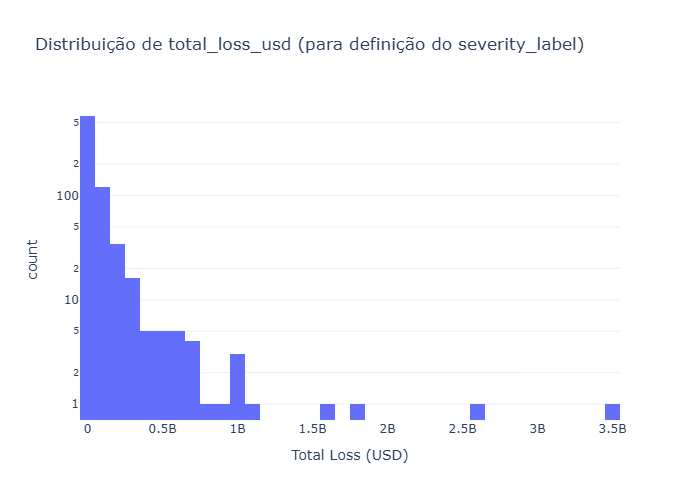

In [73]:
# ============================================================
# 6.2 - Criação do severity_label
# ============================================================

# Análise da distribuição de total_loss_usd antes de criar o label
print("Distribuição de total_loss_usd (base para severity_label):")
print(df_gold["total_loss_usd"].describe())

print(f"\nPercentis:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    val = df_gold["total_loss_usd"].quantile(p/100)
    print(f"  P{p}: ${val:,.2f}")

# Histograma para visualizar antes de decidir
fig = px.histogram(
    df_gold.dropna(subset=["total_loss_usd"]),
    x="total_loss_usd",
    nbins=50,
    title="Distribuição de total_loss_usd (para definição do severity_label)",
    labels={"total_loss_usd": "Total Loss (USD)"},
    log_y=True
)
fig.update_layout(template="plotly_white")
fig.show()

In [74]:
# ============================================================
# 6.3 - Definição do severity_label via quartis
# ============================================================

# Usar quartis para definir severidade (documentado)
# Somente para registros com total_loss_usd disponível
q25 = df_gold["total_loss_usd"].quantile(0.25)
q50 = df_gold["total_loss_usd"].quantile(0.50)
q75 = df_gold["total_loss_usd"].quantile(0.75)

print(f"Thresholds (quartis):")
print(f"  Q25 (low/medium):      ${q25:,.2f}")
print(f"  Q50 (medium/high):     ${q50:,.2f}")
print(f"  Q75 (high/critical):   ${q75:,.2f}")

def assign_severity(loss):
    if pd.isna(loss):
        return np.nan
    if loss <= q25:
        return "low"
    elif loss <= q50:
        return "medium"
    elif loss <= q75:
        return "high"
    else:
        return "critical"

df_gold["severity_label"] = df_gold["total_loss_usd"].apply(assign_severity)

print(f"\nDistribuição do severity_label:")
print(df_gold["severity_label"].value_counts().to_string())
print(f"\nNaN (sem total_loss): {df_gold['severity_label'].isna().sum()}")

Thresholds (quartis):
  Q25 (low/medium):      $6,166,440.87
  Q50 (medium/high):     $16,564,914.86
  Q75 (high/critical):   $52,595,854.40

Distribuição do severity_label:
severity_label
low         195
critical    195
medium      194
high        194

NaN (sem total_loss): 72


In [75]:
# ============================================================
# 6.4 - Remoção de colunas com data leakage + Checklist
# ============================================================

# Definição das colunas a remover com justificativa
LEAKAGE_CHECKLIST = {
    # Colunas que definem o label (ou são derivadas dele)
    "total_loss_usd": "Variável usada para criar o label severity_label",
    "total_loss_method": "Metadado do total_loss_usd",
    "total_loss_lower_bound": "Derivada/relacionada ao total_loss_usd",
    "total_loss_upper_bound": "Derivada/relacionada ao total_loss_usd",
    "inflation_adjusted_usd": "Derivada do total_loss_usd ajustada por inflação",
    "cpi_index_used": "Metadado do ajuste de inflação",
    "loss_ratio": "Derivada de direct_loss/total_loss (total_loss define o label)",
    
    # Metadados administrativos / curadoria
    "review_flag": "Flag de revisão interna — não disponível no momento do incidente",
    "quality_score": "Score de curadoria do dataset — não é feature real",
    "quality_grade": "Grade derivada do quality_score",
    "quality_flags_str": "Flags de qualidade internas do pipeline",
    "is_valid": "Flag de validação interna do pipeline",
    
    # Informações pós-incidente (futuro)
    "abnormal_return_1d": "Retorno anormal — informação pós-incidente",
    "abnormal_return_7d": "Retorno anormal — informação pós-incidente",
    "abnormal_return_30d": "Retorno anormal — informação pós-incidente",
    "car_neg1_to_pos1": "CAR — informação pós-incidente",
    "car_0_to_7": "CAR — informação pós-incidente",
    "car_0_to_30": "CAR — informação pós-incidente",
    "car_0_to_90": "CAR — informação pós-incidente",
    "t_statistic_1d": "Estatística pós-incidente",
    "p_value_1d": "Estatística pós-incidente",
    "t_statistic_30d": "Estatística pós-incidente",
    "p_value_30d": "Estatística pós-incidente",
    "price_1d_after": "Preço pós-incidente",
    "price_7d_after": "Preço pós-incidente",
    "price_30d_after": "Preço pós-incidente",
    "post_incident_volatility_30d": "Volatilidade pós-incidente",
    "days_to_price_recovery": "Tempo de recuperação — informação futura",
    "volume_disclosure_day": "Volume no dia da divulgação — pode ser pós-incidente",
    "volume_ratio_disclosure": "Ratio de volume na divulgação — pós-incidente",
    
    # Identificadores e textos não-preditivos
    "company_name": "Identificador — vazamento de informação específica",
    "stock_ticker": "Identificador — vazamento de informação específica",
    "attack_chain": "Texto narrativo longo — não estruturado para ML direto",
    "data_source_primary": "URL — não é feature preditiva",
    "data_source_secondary": "URL — não é feature preditiva",
    "attributed_group": "Grupo atribuído — pode não ser conhecido no momento do incidente",
    
    # Datas originais (já extraímos features delas)
    "incident_date": "Já extraímos year, month, dow",
    "discovery_date": "Já extraímos days_to_discovery",
    "disclosure_date": "Já extraímos days_to_disclosure",
    "incident_date_estimated": "Metadado da data",
}

# Exibir checklist formatado
print("=" * 90)
print("📋 CHECKLIST ANTI-LEAKAGE")
print("=" * 90)
checklist_data = []
for col, reason in LEAKAGE_CHECKLIST.items():
    exists = col in df_gold.columns
    checklist_data.append({
        "Coluna": col,
        "Presente no dataset": "✅" if exists else "❌",
        "Ação": "REMOVER",
        "Justificativa": reason
    })

df_checklist = pd.DataFrame(checklist_data)
display(df_checklist)

# Persistir a checklist para entrega
checklist_md_path = os.path.join(REPORTS_DIR, "anti_leakage_checklist.md")
checklist_csv_path = os.path.join(REPORTS_DIR, "anti_leakage_checklist.csv")
df_checklist.to_csv(checklist_csv_path, index=False)
with open(checklist_md_path, "w", encoding="utf-8") as f:
    f.write("# Checklist Anti-Leakage\n\n")
    f.write(df_checklist.to_string(index=False))

print(f"\n✅ Checklist salvo em: {checklist_md_path}")
print(f"✅ Checklist CSV salvo em: {checklist_csv_path}")

# Remover colunas
cols_to_remove = [c for c in LEAKAGE_CHECKLIST.keys() if c in df_gold.columns]
# Também remover duplicadas do merge (sufixos _fin, _mkt)
suffix_cols = [c for c in df_gold.columns if c.endswith("_fin") or c.endswith("_mkt")]
cols_to_remove.extend(suffix_cols)

print(f"\nColunas removidas: {len(cols_to_remove)}")
df_gold = df_gold.drop(columns=cols_to_remove, errors="ignore")
print(f"Shape final: {df_gold.shape}")
print(f"\nColunas restantes:")
for i, col in enumerate(df_gold.columns):
    print(f"  {i+1}. {col} ({df_gold[col].dtype})")

📋 CHECKLIST ANTI-LEAKAGE


,Coluna,Presente no dataset,Ação,Justificativa
0,total_loss_usd,✅,REMOVER,Variável usada para criar o label severity_label
1,total_loss_method,✅,REMOVER,Metadado do total_loss_usd
2,total_loss_lower_bound,✅,REMOVER,Derivada/relacionada ao total_loss_usd
3,total_loss_upper_bound,✅,REMOVER,Derivada/relacionada ao total_loss_usd
4,inflation_adjusted_usd,✅,REMOVER,Derivada do total_loss_usd ajustada por inflação
5,cpi_index_used,✅,REMOVER,Metadado do ajuste de inflação
6,loss_ratio,✅,REMOVER,Derivada de direct_loss/total_loss (total_loss...
7,review_flag,✅,REMOVER,Flag de revisão interna — não disponível no mo...
8,quality_score,✅,REMOVER,Score de curadoria do dataset — não é feature ...
9,quality_grade,✅,REMOVER,Grade derivada do quality_score



✅ Checklist salvo em: C:\Users\vitho\Projeto-ciencia-dados\reports\anti_leakage_checklist.md
✅ Checklist CSV salvo em: C:\Users\vitho\Projeto-ciencia-dados\reports\anti_leakage_checklist.csv

Colunas removidas: 41
Shape final: (850, 39)

Colunas restantes:
  1. incident_id (object)
  2. company_revenue_usd (float64)
  3. country_hq (object)
  4. industry_primary (object)
  5. industry_secondary (object)
  6. employee_count (int64)
  7. is_public_company (bool)
  8. attack_vector_primary (object)
  9. attack_vector_secondary (object)
  10. attribution_confidence (object)
  11. data_compromised_records (float64)
  12. data_type (object)
  13. systems_affected (object)
  14. downtime_hours (float64)
  15. data_source_type (object)
  16. confidence_tier (int64)
  17. incident_year (int32)
  18. incident_month (int32)
  19. incident_dow (int32)
  20. days_to_discovery (int64)
  21. days_to_disclosure (int64)
  22. direct_loss_usd (float64)
  23. direct_loss_method (object)
  24. ransom_dem

In [76]:
# ============================================================
# 6.5 - Filtrar registros com label e salvar Gold
# ============================================================

# Remover registros sem label (não têm total_loss_usd)
n_before = len(df_gold)
df_gold = df_gold.dropna(subset=["severity_label"])
n_after = len(df_gold)
print(f"Registros com label: {n_after} / {n_before} ({n_before - n_after} sem label removidos)")

# Salvar
gold_csv_path = os.path.join(GOLD_DIR, "dataset_ml_final.csv")
gold_parquet_path = os.path.join(GOLD_DIR, "dataset_ml_final.parquet")
df_gold.to_csv(gold_csv_path, index=False)
df_gold.to_parquet(gold_parquet_path, index=False)
print(f"\n✅ Salvo: {gold_csv_path}")
print(f"✅ Salvo: {gold_parquet_path}")
print(f"   Shape: {df_gold.shape}")
print(f"   Label distribution:")
print(df_gold["severity_label"].value_counts().to_string())

Registros com label: 778 / 850 (72 sem label removidos)

✅ Salvo: C:\Users\vitho\Projeto-ciencia-dados\data\gold\dataset_ml_final.csv
✅ Salvo: C:\Users\vitho\Projeto-ciencia-dados\data\gold\dataset_ml_final.parquet
   Shape: (778, 39)
   Label distribution:
severity_label
low         195
critical    195
medium      194
high        194


---
## 7. Análise Exploratória dos Dados (EDA)

Visualizações gráficas para compreensão da estrutura dos dados e identificação de padrões.

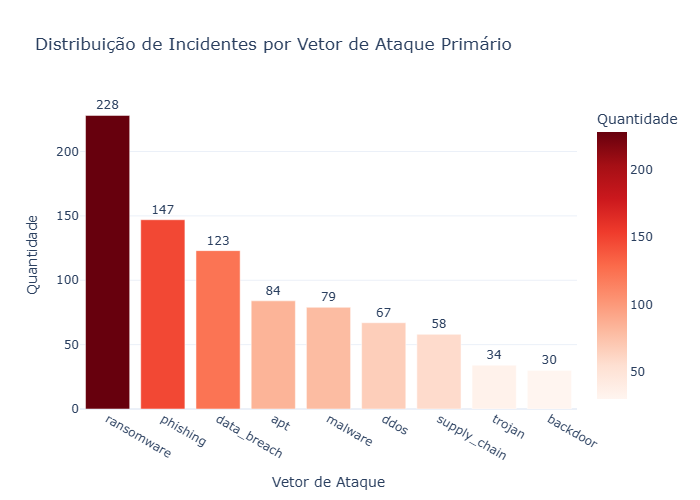

In [77]:
# ============================================================
# 7.1 - Gráfico 1: Distribuição por Vetor de Ataque
# ============================================================
attack_counts = df_inc_s["attack_vector_primary"].value_counts().reset_index()
attack_counts.columns = ["attack_vector", "count"]

fig1 = px.bar(
    attack_counts,
    x="attack_vector",
    y="count",
    title="Distribuição de Incidentes por Vetor de Ataque Primário",
    labels={"attack_vector": "Vetor de Ataque", "count": "Quantidade"},
    color="count",
    color_continuous_scale="Reds",
    text="count"
)
fig1.update_layout(template="plotly_white", showlegend=False)
fig1.update_traces(textposition="outside")
fig1.show()

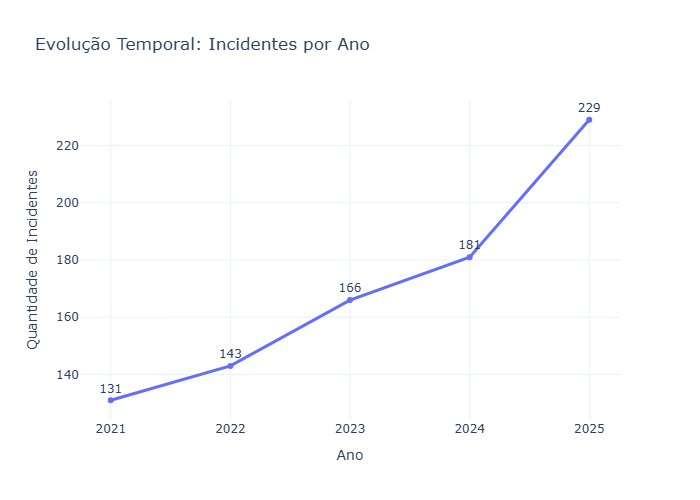

In [78]:
# ============================================================
# 7.2 - Gráfico 2: Evolução Temporal dos Incidentes
# ============================================================
if "incident_year" in df_inc_s.columns:
    yearly = df_inc_s.groupby("incident_year").size().reset_index(name="count")
    
    fig2 = px.line(
        yearly,
        x="incident_year",
        y="count",
        title="Evolução Temporal: Incidentes por Ano",
        labels={"incident_year": "Ano", "count": "Quantidade de Incidentes"},
        markers=True,
        text="count"
    )
    fig2.update_layout(template="plotly_white")
    fig2.update_traces(textposition="top center", line=dict(width=3))
    fig2.show()
else:
    print("⚠ incident_year não disponível")

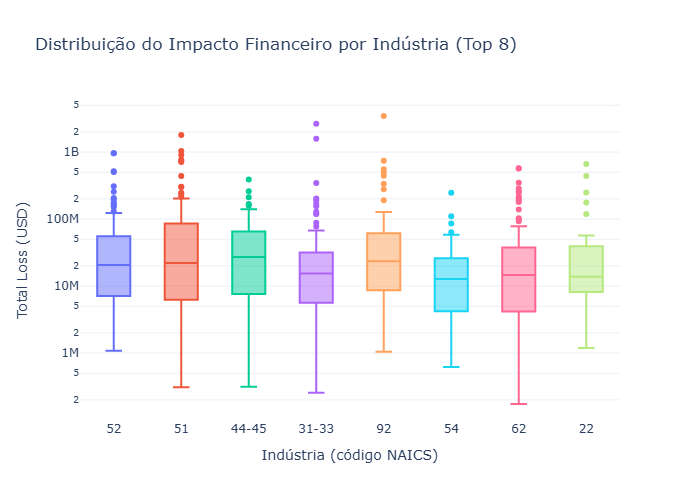

In [79]:
# ============================================================
# 7.3 - Gráfico 3: Impacto Financeiro por Indústria (Boxplot)
# ============================================================

# Merge temporário para ter industry + total_loss juntos
df_eda = df_inc_s[["incident_id", "industry_primary"]].merge(
    df_fin_s[["incident_id", "total_loss_usd"]], on="incident_id", how="inner"
)
df_eda = df_eda.dropna(subset=["total_loss_usd", "industry_primary"])

# Top 8 indústrias por frequência
top_industries = df_eda["industry_primary"].value_counts().head(8).index
df_eda_top = df_eda[df_eda["industry_primary"].isin(top_industries)]

fig3 = px.box(
    df_eda_top,
    x="industry_primary",
    y="total_loss_usd",
    title="Distribuição do Impacto Financeiro por Indústria (Top 8)",
    labels={"industry_primary": "Indústria (código NAICS)", "total_loss_usd": "Total Loss (USD)"},
    color="industry_primary",
    log_y=True
)
fig3.update_layout(template="plotly_white", showlegend=False)
fig3.show()

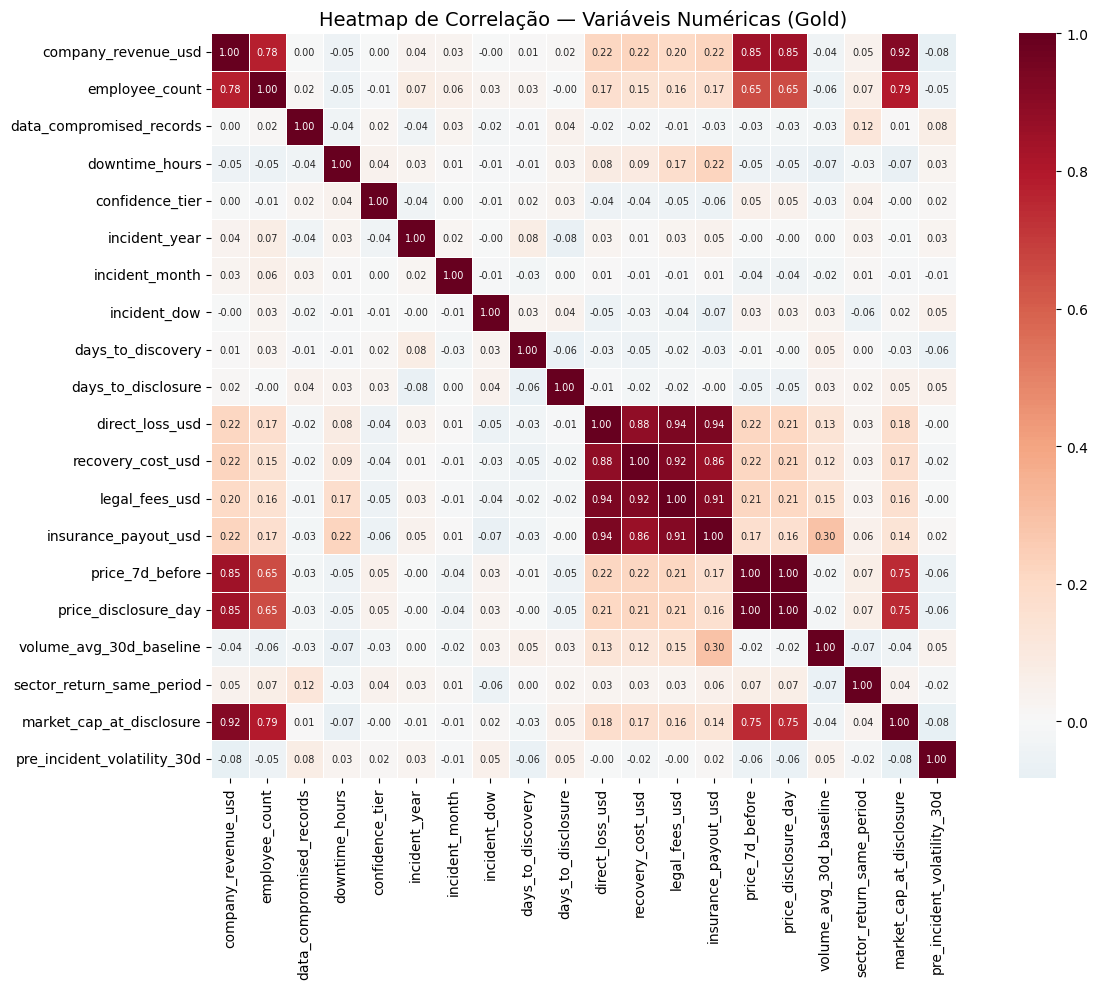

In [80]:
# ============================================================
# 7.4 - Gráfico 4: Heatmap de Correlação (variáveis numéricas)
# ============================================================
numeric_cols = df_gold.select_dtypes(include=[np.number]).columns.tolist()
# Remover colunas com muitos NaN
valid_cols = [c for c in numeric_cols if df_gold[c].notna().mean() > 0.3]

if len(valid_cols) > 2:
    corr_matrix = df_gold[valid_cols].corr()
    
    fig4, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap="RdBu_r", 
        center=0,
        square=True,
        linewidths=0.5,
        ax=ax,
        annot_kws={"size": 7}
    )
    ax.set_title("Heatmap de Correlação — Variáveis Numéricas (Gold)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Poucas variáveis numéricas para correlação")

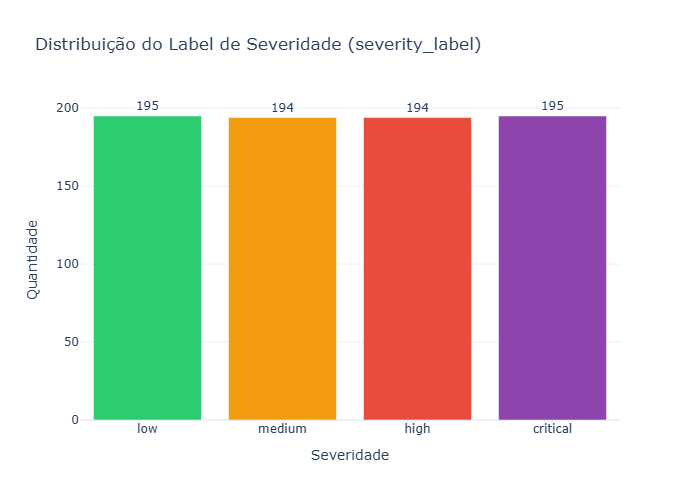

In [81]:
# ============================================================
# 7.5 - Gráfico 5: Distribuição do severity_label
# ============================================================
severity_counts = df_gold["severity_label"].value_counts().reset_index()
severity_counts.columns = ["severity", "count"]

# Ordenar
order = ["low", "medium", "high", "critical"]
severity_counts["severity"] = pd.Categorical(severity_counts["severity"], categories=order, ordered=True)
severity_counts = severity_counts.sort_values("severity")

fig5 = px.bar(
    severity_counts,
    x="severity",
    y="count",
    title="Distribuição do Label de Severidade (severity_label)",
    labels={"severity": "Severidade", "count": "Quantidade"},
    color="severity",
    color_discrete_map={"low": "#2ecc71", "medium": "#f39c12", "high": "#e74c3c", "critical": "#8e44ad"},
    text="count"
)
fig5.update_layout(template="plotly_white", showlegend=False)
fig5.update_traces(textposition="outside")
fig5.show()

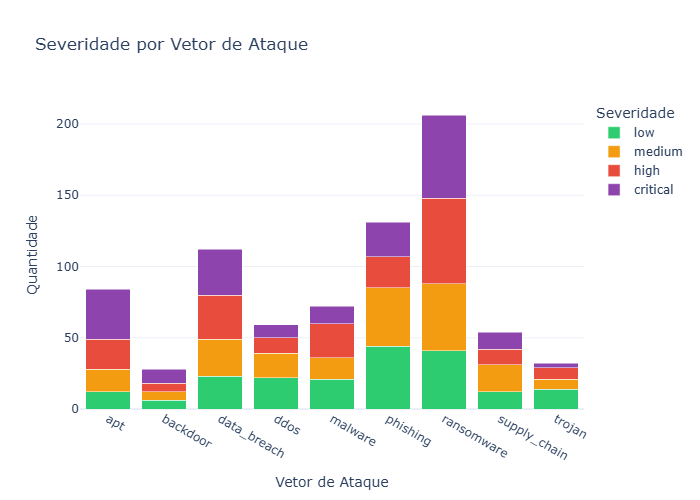

In [82]:
# ============================================================
# 7.6 - Gráfico 6: Severidade vs Vetor de Ataque (extra estratégico)
# ============================================================
df_cross = df_gold.dropna(subset=["severity_label", "attack_vector_primary"])
cross_tab = pd.crosstab(df_cross["attack_vector_primary"], df_cross["severity_label"])

# Reordenar colunas
for col in order:
    if col not in cross_tab.columns:
        cross_tab[col] = 0
cross_tab = cross_tab[order]

fig6 = px.bar(
    cross_tab.reset_index().melt(id_vars="attack_vector_primary", var_name="severity", value_name="count"),
    x="attack_vector_primary",
    y="count",
    color="severity",
    title="Severidade por Vetor de Ataque",
    labels={"attack_vector_primary": "Vetor de Ataque", "count": "Quantidade", "severity": "Severidade"},
    color_discrete_map={"low": "#2ecc71", "medium": "#f39c12", "high": "#e74c3c", "critical": "#8e44ad"},
    barmode="stack"
)
fig6.update_layout(template="plotly_white")
fig6.show()

---
## 8. Modelo de Machine Learning (Extra)

**Objetivo:** Prever a severidade do incidente (`severity_label`) com base nas características disponíveis no momento do incidente.

**Modelos:** Random Forest e Gradient Boosting (comparativo)

In [83]:
# ============================================================
# 8.1 - Preparação dos dados para ML
# ============================================================

df_ml = df_gold.copy()

# Remover coluna target e ID
target_col = "severity_label"
id_col = "incident_id"

y = df_ml[target_col].copy()
X = df_ml.drop(columns=[target_col, id_col], errors="ignore")

print(f"Shape inicial: X={X.shape}, y={y.shape}")
print(f"\nDistribuição do target:")
print(y.value_counts().to_string())

# Separar colunas por tipo
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
date_cols = X.select_dtypes(include=["datetime64"]).columns.tolist()

# Remover colunas de datetime restantes (já extraímos features)
X = X.drop(columns=date_cols, errors="ignore")
cat_cols = [c for c in cat_cols if c not in date_cols]

print(f"\nColunas categóricas ({len(cat_cols)}): {cat_cols}")
print(f"Colunas numéricas ({len(num_cols)}): {num_cols}")
if date_cols:
    print(f"Colunas datetime removidas: {date_cols}")

Shape inicial: X=(778, 37), y=(778,)

Distribuição do target:
severity_label
low         195
critical    195
medium      194
high        194

Colunas categóricas (14): ['country_hq', 'industry_primary', 'industry_secondary', 'is_public_company', 'attack_vector_primary', 'attack_vector_secondary', 'attribution_confidence', 'data_type', 'systems_affected', 'data_source_type', 'direct_loss_method', 'ransom_source', 'sector_index', 'earnings_announcement_within_7d']
Colunas numéricas (23): ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours', 'confidence_tier', 'incident_year', 'incident_month', 'incident_dow', 'days_to_discovery', 'days_to_disclosure', 'direct_loss_usd', 'ransom_demanded_usd', 'ransom_paid_usd', 'recovery_cost_usd', 'legal_fees_usd', 'regulatory_fine_usd', 'insurance_payout_usd', 'price_7d_before', 'price_disclosure_day', 'volume_avg_30d_baseline', 'sector_return_same_period', 'market_cap_at_disclosure', 'pre_incident_volatility_30d']


In [84]:
# ============================================================
# 8.2 - Encoding e tratamento de NaN
# ============================================================

# Label Encoding para categóricas
label_encoders = {}
for col in cat_cols:
    if col in X.columns:
        le = LabelEncoder()
        # Tratar NaN como categoria "MISSING"
        X[col] = X[col].fillna("MISSING").astype(str)
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le

# Preencher NaN numéricos com mediana
for col in num_cols:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].median())

# Encode do target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"Classes: {list(le_target.classes_)}")
print(f"Shape final: X={X.shape}, y={len(y_encoded)}")
print(f"\nNaN restantes: {X.isnull().sum().sum()}")

Classes: ['critical', 'high', 'low', 'medium']
Shape final: X=(778, 37), y=778

NaN restantes: 0


In [85]:
# ============================================================
# 8.3 - Split treino/teste
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nDistribuição no treino:")
for cls, name in enumerate(le_target.classes_):
    count = (y_train == cls).sum()
    print(f"  {name}: {count} ({count/len(y_train)*100:.1f}%)")

Treino: 622 amostras
Teste:  156 amostras

Distribuição no treino:
  critical: 156 (25.1%)
  high: 155 (24.9%)
  low: 156 (25.1%)
  medium: 155 (24.9%)


In [86]:
# ============================================================
# 8.4 - Treinamento: Random Forest
# ============================================================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=" * 60)
print("🌲 RANDOM FOREST — Resultados")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

🌲 RANDOM FOREST — Resultados

Accuracy: 0.9038

Classification Report:
              precision    recall  f1-score   support

    critical       0.95      0.97      0.96        39
        high       0.85      0.90      0.88        39
         low       0.95      0.90      0.92        39
      medium       0.87      0.85      0.86        39

    accuracy                           0.90       156
   macro avg       0.90      0.90      0.90       156
weighted avg       0.90      0.90      0.90       156



In [87]:
# ============================================================
# 8.5 - Treinamento: Gradient Boosting
# ============================================================
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("=" * 60)
print("🚀 GRADIENT BOOSTING — Resultados")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=le_target.classes_))

🚀 GRADIENT BOOSTING — Resultados

Accuracy: 0.9295

Classification Report:
              precision    recall  f1-score   support

    critical       0.97      0.97      0.97        39
        high       0.88      0.90      0.89        39
         low       0.97      0.97      0.97        39
      medium       0.89      0.87      0.88        39

    accuracy                           0.93       156
   macro avg       0.93      0.93      0.93       156
weighted avg       0.93      0.93      0.93       156



In [88]:
# ============================================================
# 8.6 - Comparação dos modelos
# ============================================================
print("=" * 60)
print("📊 COMPARAÇÃO DOS MODELOS")
print("=" * 60)

acc_rf = accuracy_score(y_test, y_pred_rf)
acc_gb = accuracy_score(y_test, y_pred_gb)

comparison = pd.DataFrame({
    "Modelo": ["Random Forest", "Gradient Boosting"],
    "Accuracy": [acc_rf, acc_gb],
    "Melhor": ["✅" if acc_rf >= acc_gb else "", "✅" if acc_gb > acc_rf else ""]
})
display(comparison)

# Selecionar melhor modelo para visualizações
best_model_name = "Random Forest" if acc_rf >= acc_gb else "Gradient Boosting"
best_model = rf if acc_rf >= acc_gb else gb
best_pred = y_pred_rf if acc_rf >= acc_gb else y_pred_gb
print(f"\nMelhor modelo: {best_model_name}")

📊 COMPARAÇÃO DOS MODELOS


,Modelo,Accuracy,Melhor
0,Random Forest,0.903846,
1,Gradient Boosting,0.929487,✅



Melhor modelo: Gradient Boosting


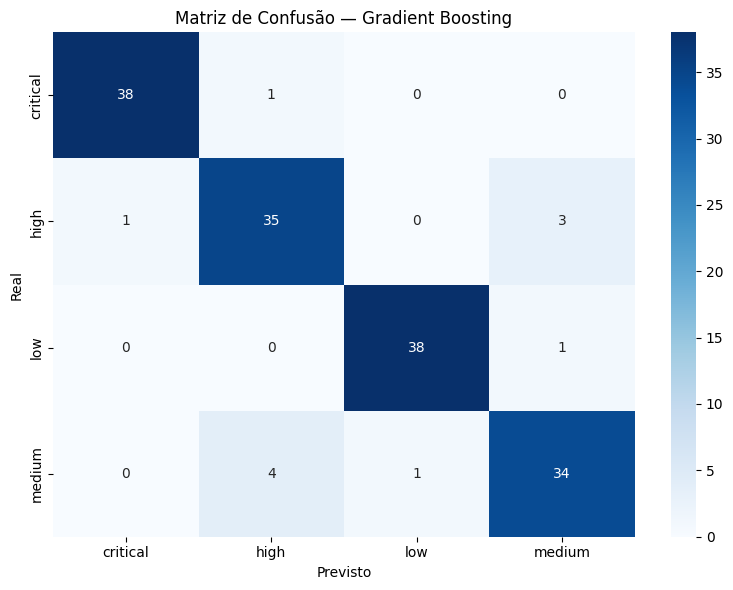

In [89]:
# ============================================================
# 8.7 - Matriz de Confusão (melhor modelo)
# ============================================================
cm = confusion_matrix(y_test, best_pred)

fig_cm, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_,
    ax=ax
)
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de Confusão — {best_model_name}")
plt.tight_layout()
plt.show()

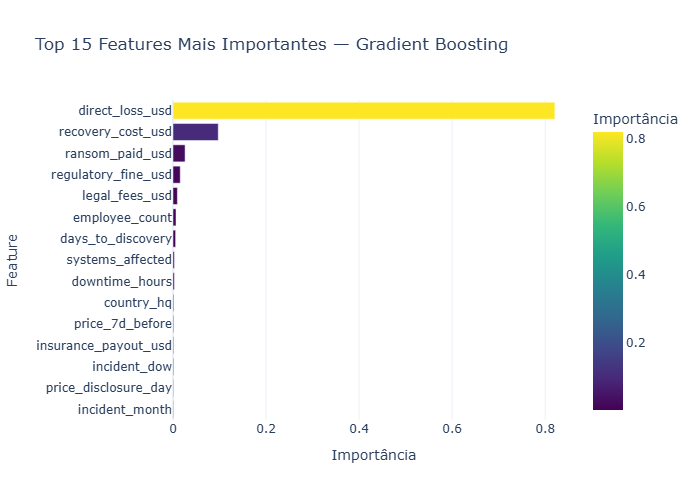

In [90]:
# ============================================================
# 8.8 - Feature Importance (melhor modelo)
# ============================================================
importances = best_model.feature_importances_
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=True).tail(15)

fig_fi = px.bar(
    feat_imp,
    x="importance",
    y="feature",
    orientation="h",
    title=f"Top 15 Features Mais Importantes — {best_model_name}",
    labels={"importance": "Importância", "feature": "Feature"},
    color="importance",
    color_continuous_scale="Viridis"
)
fig_fi.update_layout(template="plotly_white", showlegend=False)
fig_fi.show()

In [91]:
# ============================================================
# 8.9 - Salvar modelo treinado
# ============================================================
import pickle

MODEL_DIR = os.path.join(DATA_DIR, "model")
os.makedirs(MODEL_DIR, exist_ok=True)

# Salvar o melhor modelo
model_path = os.path.join(MODEL_DIR, "best_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)
print(f"✅ Modelo salvo: {model_path}")
print(f"   Tipo: {best_model_name}")

# Salvar o LabelEncoder do target
le_path = os.path.join(MODEL_DIR, "label_encoder_target.pkl")
with open(le_path, "wb") as f:
    pickle.dump(le_target, f)
print(f"✅ LabelEncoder salvo: {le_path}")

# Salvar os LabelEncoders das features categóricas
le_features_path = os.path.join(MODEL_DIR, "label_encoders_features.pkl")
with open(le_features_path, "wb") as f:
    pickle.dump(label_encoders, f)
print(f"✅ LabelEncoders das features salvo: {le_features_path}")

# Salvar metadados do modelo (features, classes, métricas)
model_metadata = {
    "model_name": best_model_name,
    "accuracy": float(accuracy_score(y_test, best_pred)),
    "features": list(X.columns),
    "target_classes": list(le_target.classes_),
    "n_train": len(X_train),
    "n_test": len(X_test),
    "random_state": 42,
    "created_at": datetime.now(timezone.utc).isoformat(),
}
meta_path = os.path.join(MODEL_DIR, "model_metadata.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=2, ensure_ascii=False)
print(f"✅ Metadados salvos: {meta_path}")

print(f"\n📁 Arquivos do modelo em: {MODEL_DIR}")
for fname in os.listdir(MODEL_DIR):
    fpath = os.path.join(MODEL_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"   {fname} ({size_kb:.1f} KB)")

✅ Modelo salvo: C:\Users\vitho\Projeto-ciencia-dados\data\model\best_model.pkl
   Tipo: Gradient Boosting
✅ LabelEncoder salvo: C:\Users\vitho\Projeto-ciencia-dados\data\model\label_encoder_target.pkl
✅ LabelEncoders das features salvo: C:\Users\vitho\Projeto-ciencia-dados\data\model\label_encoders_features.pkl
✅ Metadados salvos: C:\Users\vitho\Projeto-ciencia-dados\data\model\model_metadata.json

📁 Arquivos do modelo em: C:\Users\vitho\Projeto-ciencia-dados\data\model
   best_model.pkl (1763.8 KB)
   label_encoders_features.pkl (26.4 KB)
   label_encoder_target.pkl (0.3 KB)
   model_metadata.json (1.3 KB)


---
## 9. Conclusão

### Entregáveis Produzidos

| # | Entregável | Status |
|---|---|---|
| 1 | Notebook principal | ✅ |
| 2 | Parquets da camada Bronze (3 arquivos) | ✅ |
| 3 | Parquets da camada Silver (3 arquivos) | ✅ |
| 4 | **Extra**: Parquet da camada Gold (dataset ML) | ✅ |
| 5 | Metadados de ingestão (JSON) | ✅ |
| 6 | Relatório de qualidade dos dados | ✅ |
| 7 | Data lineage (diagrama Mermaid) | ✅ |
| 8 | Tabela checklist anti-leakage | ✅ |
| 9 | EDA com 6 gráficos | ✅ |
| 10 | README.md | ✅ |
| 11 | **Extra**: Modelo ML (Random Forest + Gradient Boosting) | ✅ |

### Arquitetura de Dados (Medallion)

- **Bronze**: Dados brutos e rastreáveis — mínima transformação, preservação da origem
- **Silver**: Dados limpos e validados — quality_flags, features derivadas, por domínio
- **Gold**: Dados prontos para consumo específico (ML) — merge, label, anti-leakage

### Decisões Técnicas Documentadas

1. **Label**: `severity_label` baseado em quartis de `total_loss_usd` (low/medium/high/critical)
2. **Anti-leakage**: Removidas colunas pós-incidente, identificadores, e as que definem o label
3. **Quality flags**: Lista padronizada de strings, `is_valid = len(quality_flags) == 0`
4. **Merge**: LEFT JOIN na Gold — empresas privadas sem dados de mercado mantidas com NaN
5. **Bronze não decide**: Tipos convertidos quando possível, mantidos como string quando há falha